In [ ]:
from datasets import load_dataset

ds = load_dataset(
    "UmarRamzan/common-voice-urdu-processed",
    cache_dir="./urdu_dataset"
)
ds.save_to_disk("urdu_dataset")


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds.save_to_disk("urdu_dataset")

In [9]:
!pip install "soundfile>=0.12.1"


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [3]:
## load a sample row from ds[train]
sample = ds["train"][0]
print(sample)



{'path': '/root/.cache/huggingface/datasets/downloads/extracted/98bf2841c44feb87b01d6be50c6f7419f1ac73fbf85cbe37236d236156bc5b3f/ur_train_0/common_voice_ur_31857979.mp3', 'audio': {'path': 'common_voice_ur_31857979.mp3', 'array': array([ 3.41060513e-13, -9.09494702e-13, -2.27373675e-12, ...,
       -4.77751144e-07, -4.93692141e-07, -3.46486559e-07]), 'sampling_rate': 48000}, 'sentence': 'معاشی مواقع پیدا ہوں', 'variant': ''}


In [5]:
print(sample["sentence"])
print(sample["audio"])

معاشی مواقع پیدا ہوں
{'path': 'common_voice_ur_31857979.mp3', 'array': array([ 3.41060513e-13, -9.09494702e-13, -2.27373675e-12, ...,
       -4.77751144e-07, -4.93692141e-07, -3.46486559e-07]), 'sampling_rate': 48000}


## SAMPLE AUDIO

In [25]:
import IPython.display as ipd

def play_audio(audio_path,rate = 48000):
    return ipd.Audio(audio_path, rate=rate)

audio = sample["audio"]["array"]
sr = sample["audio"]["sampling_rate"]

print(sr)
play_audio(audio,sr)

48000


In [8]:
print(ds["train"].features)

{'path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=48000, mono=True, decode=True, id=None), 'sentence': Value(dtype='string', id=None), 'variant': Value(dtype='string', id=None)}


## SIZE 

In [9]:
print(ds)
print("Train size:", len(ds["train"]))
print("Test size:", len(ds["test"]))
print(ds["train"].features)

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'sentence', 'variant'],
        num_rows: 9425
    })
    test: Dataset({
        features: ['path', 'audio', 'sentence', 'variant'],
        num_rows: 4056
    })
})
Train size: 9425
Test size: 4056
{'path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=48000, mono=True, decode=True, id=None), 'sentence': Value(dtype='string', id=None), 'variant': Value(dtype='string', id=None)}


## Text length distribution 


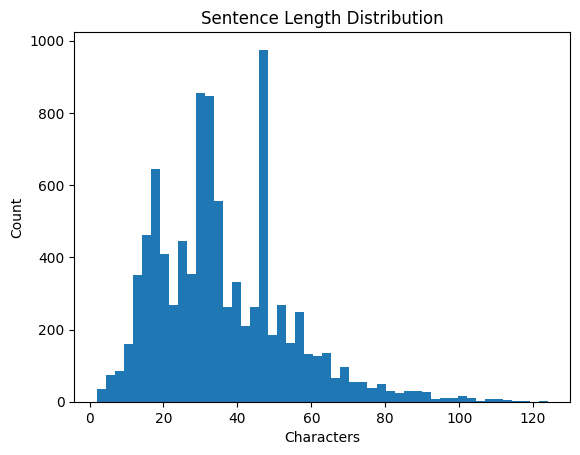

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

train = ds["train"]

text_lengths = [len(x["sentence"]) for x in train]

plt.hist(text_lengths, bins=50)
plt.title("Sentence Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

## Audio Duration Distribution

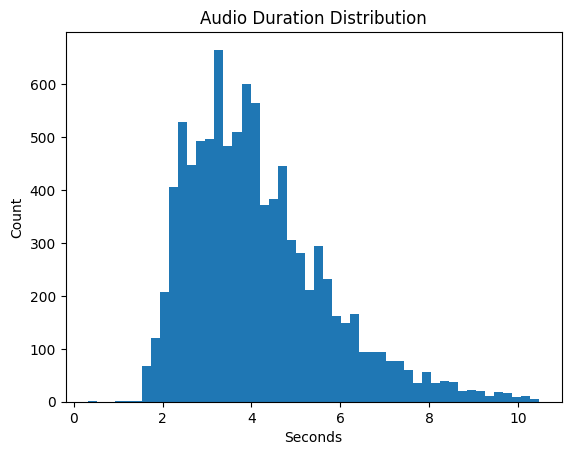

In [11]:
import numpy as np

durations = []

for x in train:
    audio = x["audio"]
    durations.append(len(audio["array"]) / audio["sampling_rate"])

plt.hist(durations, bins=50)
plt.title("Audio Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

## Text Length vs Audio Duration

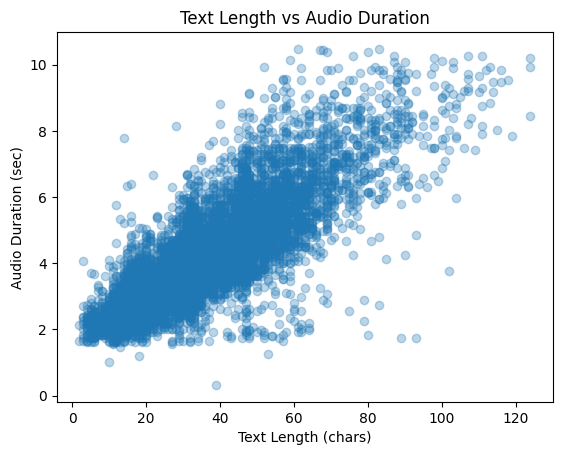

In [12]:
plt.scatter(text_lengths, durations, alpha=0.3)
plt.title("Text Length vs Audio Duration")
plt.xlabel("Text Length (chars)")
plt.ylabel("Audio Duration (sec)")
plt.show()

## CHECKING FOR BAD SAMPLES


In [13]:
bad_samples = []

for i, x in enumerate(train):
    if len(x["sentence"].strip()) == 0:
        bad_samples.append(i)

print("Empty text samples:", len(bad_samples))

Empty text samples: 1


There is 1 bad sample

In [ ]:
print(ds["train"][bad_samples])

{'path': ['/root/.cache/huggingface/datasets/downloads/extracted/02089132964e2964406fc421f5ea193095fd728594980144dd1264b969cccd62/ur_dev_0/common_voice_ur_38469969.mp3'], 'audio': [{'path': 'common_voice_ur_38469969.mp3', 'array': array([-2.84217094e-14, -1.87583282e-12, -2.27373675e-12, ...,
        5.09568736e-06,  2.03378568e-06,  1.23202926e-06]), 'sampling_rate': 48000}], 'sentence': ['   '], 'variant': ['']}


In [ ]:
## CHECKING IF AUDIO FOR THIS 0 text sample exist
idx = bad_samples[0]

sample = ds["train"][idx]
print(None if len(sample["sentence"])  != 0 else sample["sentence"])
play_audio(sample["audio"]["array"])

None


## MOST COMMON WORDS

In [16]:
from collections import Counter

words = []
for x in train:
    words.extend(x["sentence"].split())

common = Counter(words).most_common(20)
print(common)

[('ہے', 2753), ('کے', 2099), ('میں', 2065), ('کی', 1997), ('کا', 1576), ('سے', 1357), ('ہیں', 1137), ('کو', 1025), ('اور', 933), ('اس', 849), ('نہیں', 802), ('یہ', 777), ('نے', 712), ('تو', 658), ('پر', 648), ('بھی', 636), ('کیا', 580), ('ایک', 571), ('ہو', 524), ('کہ', 521)]


## DETECTING OUTLIERS

In [ ]:
outliers = []

for i, x in enumerate(train):
    dur = len(x["audio"]["array"]) / x["audio"]["sampling_rate"]
    if dur > 15:   # threshold
        outliers.append((i, dur))

print("Long audio samples:", len(outliers))
print(outliers[:10])

## SPLIT INTO TRAIN(80)/VAL(10)/TEST(10)

In [40]:
from datasets import DatasetDict

dataset = ds["train"]

split = dataset.train_test_split(test_size=0.2, seed=42)

train_data = split["train"]
temp = split["test"]

val_test = temp.train_test_split(test_size=0.5, seed=42)

ds_split = DatasetDict({
    "train": train_data,
    "validation": val_test["train"],
    "test": val_test["test"]
})

print(ds_split)

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'sentence', 'variant'],
        num_rows: 7540
    })
    validation: Dataset({
        features: ['path', 'audio', 'sentence', 'variant'],
        num_rows: 942
    })
    test: Dataset({
        features: ['path', 'audio', 'sentence', 'variant'],
        num_rows: 943
    })
})


## CONVERTING HUGGING FACE DATA INTO PROPER TRAIN/VAL/TEST DIRECTORIES

also converted sample sr from 48000 = 22050 for proper compatibility with xtts model

In [41]:
import os
import soundfile as sf
import librosa

def convert_split(dataset, output_dir, target_sr=22050):
    wav_dir = os.path.join(output_dir, "wavs")
    os.makedirs(wav_dir, exist_ok=True)

    metadata = []
    
    # initialize counters for logging
    stats = {
        "total": 0,
        "saved": 0,
        "skipped_empty_text": 0,
        "skipped_too_short": 0
    }

    for i, sample in enumerate(dataset):
        stats["total"] += 1
        audio = sample["audio"]["array"]
        sr = sample["audio"]["sampling_rate"]
        text = sample["sentence"]

        # skip bad samples (Empty/None Text) 
        if text is None or len(text.strip()) == 0:
            stats["skipped_empty_text"] += 1
            continue

        # clean text 
        text = text.strip().replace("\n", " ")

        #  resample 
        if sr != target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
            sr = target_sr

        # skip very short clips (< 0.5s) 
        if len(audio) < sr * 0.5:
            stats["skipped_too_short"] += 1
            continue

        #  filename 
        fname = f"{i:06d}.wav"
        fpath = os.path.join(wav_dir, fname)

        # save wav 
        sf.write(fpath, audio, sr)

        # metadata row 
        metadata.append(f"{fname[:-4]}|{text}")
        stats["saved"] += 1

    # save metadata
    metadata_path = os.path.join(output_dir, "metadata.csv")
    with open(metadata_path, "w", encoding="utf-8") as f:
        f.write("\n".join(metadata))

    # Detailed logging
    print(f"Processing Complete: {output_dir}")
    print(f"  - Total samples seen:  {stats['total']}")
    print(f"  - Successfully saved: {stats['saved']}")
    print(f"  - Skipped (Empty txt): {stats['skipped_empty_text']}")
    print(f"  - Skipped (Too short): {stats['skipped_too_short']}")
    print("-" * 30)



In [42]:
convert_split(ds_split["train"], "xtts_dataset/train")
convert_split(ds_split["validation"], "xtts_dataset/val")
convert_split(ds_split["test"], "xtts_dataset/test")

Processing Complete: xtts_dataset/train
  - Total samples seen:  7540
  - Successfully saved: 7538
  - Skipped (Empty txt): 1
  - Skipped (Too short): 1
------------------------------
Processing Complete: xtts_dataset/val
  - Total samples seen:  942
  - Successfully saved: 942
  - Skipped (Empty txt): 0
  - Skipped (Too short): 0
------------------------------
Processing Complete: xtts_dataset/test
  - Total samples seen:  943
  - Successfully saved: 943
  - Skipped (Empty txt): 0
  - Skipped (Too short): 0
------------------------------


In [2]:
import pandas as pd

df = pd.read_csv("/Users/robbannn/Desktop/PROJECTS/urduTTS/xtts_dataset/train/metadata.csv", sep="|", header=None)
print(df.head())
print("Train size:", len(df))

   0                                                  1
0  0               رونا ہے کہ کتنی شامیں ویران رہتی ہیں
1  1                    پرانے کالج کا بیڑہ غرق نہ کیجئے
2  2                               خادم پاکستان بننے کے
3  3                  خوشبو ہوا کی لہروں پر سفر کرتی ہے
4  4  جس کے سبب لکھنے کو من نہ کیا کیونکہ پاکستان کی...
Train size: 7538
